# Actividad individual opcional Nº 2 — Análisis Exploratorio de Datos (EDA)

**Mousist, Jorge Martín** — Inteligencia Artificial (IUA)

**Consigna:** realizar un EDA básico del dataset seleccionado: estadística descriptiva, tipos de
variables, relaciones entre variables e incluir al menos 3 gráficos.

**Dataset elegido:** *FIFA World Cup 2026 — Squads and Players* (Kaggle). Se usan dos de sus
tablas, `squads_and_players.csv` (un registro por jugador convocado) y `teams.csv` (un registro
por selección), que se cruzan por `team_id`. La unidad de análisis es el **jugador**.

## 1. Carga de los datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)

jugadores = pd.read_csv('dataset/squads_and_players.csv')
equipos = pd.read_csv('dataset/teams.csv')

print('jugadores:', jugadores.shape)
print('equipos  :', equipos.shape)
jugadores.head(3)

jugadores: (1248, 10)
equipos  : (48, 8)


,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals
0,1,1,José Raúl Rangel,GK,CD Guadalajara,8933646,15,2000-02-25,190,0
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,1997-12-10,176,3
2,3,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,1997-02-24,191,4


In [2]:
# Se cruzan las dos tablas por team_id y se agregan dos variables derivadas:
# la edad al inicio del torneo y el valor de mercado expresado en millones de euros.
df = jugadores.merge(equipos, on='team_id')

df['edad'] = ((pd.Timestamp('2026-06-11') - pd.to_datetime(df['date_of_birth'])).dt.days / 365.25).astype(int)
df['valor_millones'] = (df['market_value_eur'] / 1_000_000).round(2)

df = df[['player_name', 'team_name', 'confederation', 'position',
         'edad', 'height_cm', 'valor_millones', 'caps', 'goals', 'elo_rating']]

print(f'Dataset de análisis: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dataset de análisis: 1248 filas × 10 columnas


,player_name,team_name,confederation,position,edad,height_cm,valor_millones,caps,goals,elo_rating
0,José Raúl Rangel,Mexico,CONCACAF,GK,26,190,8.93,15,0,1810
1,Jorge Eduardo Sanchez,Mexico,CONCACAF,DEF,28,176,24.63,59,3,1810
2,César Jasib Montes,Mexico,CONCACAF,DEF,29,191,10.91,69,4,1810
3,Edson Omar Alvarez,Mexico,CONCACAF,DEF,28,180,10.88,100,7,1810
4,Johan Felipe Vasquez,Mexico,CONCACAF,DEF,27,182,18.27,47,3,1810


## 2. Primera inspección: nulos y duplicados

In [3]:
print('Valores nulos por columna:')
print(df.isna().sum())
print()
print('Filas duplicadas:', df.duplicated().sum())

Valores nulos por columna:
player_name       0
team_name         0
confederation     0
position          0
edad              0
height_cm         0
valor_millones    0
caps              0
goals             0
elo_rating        0
dtype: int64

Filas duplicadas: 0


El dataset está **completo**: no hay valores nulos ni filas duplicadas, así que no hace falta
ninguna tarea de limpieza previa al análisis.

## 3. Tipos de variables

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player_name     1248 non-null   str    
 1   team_name       1248 non-null   str    
 2   confederation   1248 non-null   str    
 3   position        1248 non-null   str    
 4   edad            1248 non-null   int64  
 5   height_cm       1248 non-null   int64  
 6   valor_millones  1248 non-null   float64
 7   caps            1248 non-null   int64  
 8   goals           1248 non-null   int64  
 9   elo_rating      1248 non-null   int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 97.6 KB


In [5]:
tipos = pd.DataFrame([
    ('player_name',    'categórica nominal', 'texto',  'nombre del jugador (identificador)'),
    ('team_name',      'categórica nominal', 'texto',  'selección a la que pertenece'),
    ('confederation',  'categórica nominal', 'texto',  'confederación de la selección'),
    ('position',       'categórica nominal', 'texto',  'puesto: GK, DEF, MID, FWD'),
    ('edad',           'numérica discreta',  'entero', 'años cumplidos al 11/06/2026'),
    ('height_cm',      'numérica continua',  'entero', 'altura en centímetros'),
    ('valor_millones', 'numérica continua',  'real',   'valor de mercado en millones de €'),
    ('caps',           'numérica discreta',  'entero', 'partidos jugados con la selección'),
    ('goals',          'numérica discreta',  'entero', 'goles con la selección'),
    ('elo_rating',     'numérica continua',  'entero', 'rating Elo del equipo del jugador'),
], columns=['variable', 'tipo', 'formato', 'descripción'])

tipos

,variable,tipo,formato,descripción
0,player_name,categórica nominal,texto,nombre del jugador (identificador)
1,team_name,categórica nominal,texto,selección a la que pertenece
2,confederation,categórica nominal,texto,confederación de la selección
3,position,categórica nominal,texto,"puesto: GK, DEF, MID, FWD"
4,edad,numérica discreta,entero,años cumplidos al 11/06/2026
5,height_cm,numérica continua,entero,altura en centímetros
6,valor_millones,numérica continua,real,valor de mercado en millones de €
7,caps,numérica discreta,entero,partidos jugados con la selección
8,goals,numérica discreta,entero,goles con la selección
9,elo_rating,numérica continua,entero,rating Elo del equipo del jugador


Hay **4 variables categóricas nominales** y **6 numéricas**. `height_cm` y `elo_rating` se tratan
como continuas aunque estén redondeadas a un entero, porque miden magnitudes continuas; `edad`,
`caps` y `goals` son conteos, es decir, discretas.

## 4. Estadística descriptiva

In [6]:
numericas = ['edad', 'height_cm', 'valor_millones', 'caps', 'goals']
df[numericas].describe().round(2)

,edad,height_cm,valor_millones,caps,goals
count,1248.00,1248.00,1248.00,1248.00,1248.00
mean,27.45,182.78,15.50,34.99,4.52
std,4.27,6.83,23.45,32.23,10.40
min,17.00,160.00,0.02,0.00,0.00
25%,24.00,178.00,2.60,11.00,0.00
50%,27.00,183.00,6.57,26.00,1.00
75%,30.00,188.00,18.00,50.00,4.00
max,43.00,205.00,200.00,229.00,143.00


In [7]:
# Medidas de tendencia central, dispersión y forma
resumen = pd.DataFrame({
    'media':      df[numericas].mean(),
    'mediana':    df[numericas].median(),
    'desvío':     df[numericas].std(),
    'CV (σ/μ)':   df[numericas].std() / df[numericas].mean(),
    'IQR':        df[numericas].quantile(0.75) - df[numericas].quantile(0.25),
    'asimetría':  df[numericas].skew(),
    'curtosis':   df[numericas].kurtosis(),
}).round(2)

resumen

,media,mediana,desvío,CV (σ/μ),IQR,asimetría,curtosis
edad,27.45,27.00,4.27,0.16,6.0,0.33,-0.09
height_cm,182.78,183.00,6.83,0.04,10.0,-0.09,-0.25
valor_millones,15.50,6.57,23.45,1.51,15.4,3.26,14.20
caps,34.99,26.00,32.23,0.92,39.0,1.61,3.40
goals,4.52,1.00,10.40,2.30,4.0,5.98,51.57


**Lectura:**

- En `edad` y `height_cm` la media y la mediana prácticamente coinciden y la asimetría es cercana
  a 0: son distribuciones **simétricas**, bien resumidas por la media.
- `valor_millones` tiene media 15,50 M€ contra mediana 6,57 M€, asimetría +3,26 y curtosis +14,2:
  una **cola derecha muy larga** producida por un puñado de estrellas. Acá la media engaña y
  conviene usar la mediana.
- El coeficiente de variación confirma el orden: `height_cm` es la variable más homogénea
  (CV 0,04) y `goals` la más dispersa (CV 2,30).

### 4.1. Variables categóricas

In [8]:
for col in ['position', 'confederation']:
    frec = pd.DataFrame({
        'frecuencia absoluta': df[col].value_counts(),
        'frecuencia relativa': (df[col].value_counts(normalize=True) * 100).round(1),
    })
    print(f'--- {col} ({df[col].nunique()} categorías) ---')
    print(frec, end='\n\n')

--- position (4 categorías) ---
          frecuencia absoluta  frecuencia relativa
position                                          
DEF                       421                 33.7
MID                       369                 29.6
FWD                       313                 25.1
GK                        145                 11.6

--- confederation (6 categorías) ---
               frecuencia absoluta  frecuencia relativa
confederation                                          
UEFA                           416                 33.3
CAF                            260                 20.8
AFC                            234                 18.8
CONCACAF                       156                 12.5
CONMEBOL                       156                 12.5
OFC                             26                  2.1



El reparto por puesto sigue la estructura habitual de un plantel (más defensores que delanteros y
sólo tres arqueros por plantel: 145 sobre 1248 jugadores). En `confederation`, UEFA aporta el 33 %
de los convocados, coherente con la cantidad de plazas europeas en el torneo.

## 5. Relaciones entre variables

In [9]:
# Relación numérica–numérica: matriz de correlación de Pearson
df[numericas + ['elo_rating']].corr().round(2)

,edad,height_cm,valor_millones,caps,goals,elo_rating
edad,1.00,0.10,-0.22,0.61,0.29,-0.01
height_cm,0.10,1.00,-0.03,-0.10,-0.06,0.06
valor_millones,-0.22,-0.03,1.00,-0.01,0.10,0.57
caps,0.61,-0.10,-0.01,1.00,0.61,0.05
goals,0.29,-0.06,0.10,0.61,1.00,0.07
elo_rating,-0.01,0.06,0.57,0.05,0.07,1.00


Las relaciones más fuertes son:

- **`edad` ~ `caps` = +0,61** y **`caps` ~ `goals` = +0,61**: cuanto más veterano es el jugador,
  más partidos y más goles acumula con su selección. Es la relación esperable, y es acumulativa.
- **`elo_rating` ~ `valor_millones` = +0,57**: los planteles de las selecciones más fuertes valen
  más. Es la relación más informativa del dataset.
- **`edad` ~ `valor_millones` = −0,22**: la relación es **negativa**. El mercado paga proyección,
  no trayectoria.
- `height_cm` no se relaciona con ninguna otra numérica (todas entre −0,10 y +0,10). Sí se
  relaciona, en cambio, con una categórica: el puesto (ver gráfico 3).

In [10]:
# Relación categórica–numérica: valor de mercado y altura según el puesto
df.groupby('position')[['valor_millones', 'height_cm', 'edad']].median().round(1)

,valor_millones,height_cm,edad
position,,,
DEF,6.0,184.0,27.0
FWD,7.7,182.0,26.0
GK,3.2,190.0,30.0
MID,7.9,180.0,27.0


Los arqueros son los más altos (mediana 190 cm) y a la vez los peor pagados (3,18 M€ de mediana,
menos de la mitad que un mediocampista). Los mediocampistas y delanteros concentran el valor.

## 6. Gráficos

Los tres gráficos siguientes cubren los tres tipos de análisis: la distribución de una variable,
la relación entre dos numéricas y la relación entre una numérica y una categórica.

### Gráfico 1 — Distribución del valor de mercado (histograma)

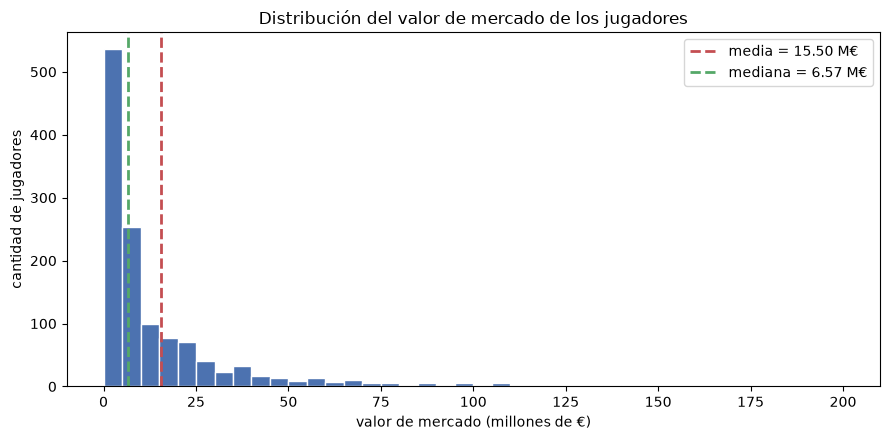

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(df['valor_millones'], bins=40, color='#4C72B0', edgecolor='white')
ax.axvline(df['valor_millones'].mean(), color='#C44E52', linestyle='--', linewidth=2,
           label=f"media = {df['valor_millones'].mean():.2f} M€")
ax.axvline(df['valor_millones'].median(), color='#55A868', linestyle='--', linewidth=2,
           label=f"mediana = {df['valor_millones'].median():.2f} M€")

ax.set_title('Distribución del valor de mercado de los jugadores')
ax.set_xlabel('valor de mercado (millones de €)')
ax.set_ylabel('cantidad de jugadores')
ax.legend()
plt.tight_layout()
plt.show()

La distribución es **fuertemente asimétrica a la derecha** (asimetría +3,26): la gran mayoría de
los jugadores vale menos de 20 M€ y una minoría se estira hasta los 200 M€. Por eso la media
(línea roja) queda muy por encima de la mediana (línea verde) y no representa bien al jugador
típico.

### Gráfico 2 — Edad vs. partidos internacionales (dispersión)

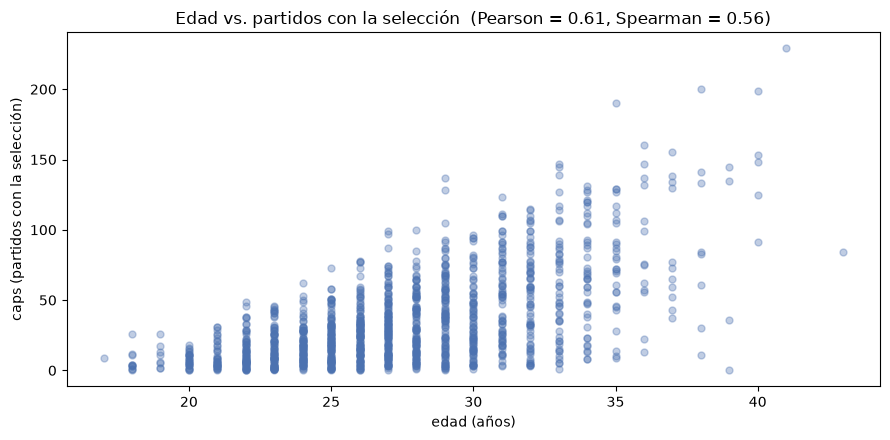

In [12]:
r_pearson = df['edad'].corr(df['caps'])
r_spearman = df['edad'].corr(df['caps'], method='spearman')

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.scatter(df['edad'], df['caps'], alpha=0.35, s=25, color='#4C72B0')

ax.set_title(f'Edad vs. partidos con la selección  (Pearson = {r_pearson:.2f}, '
             f'Spearman = {r_spearman:.2f})')
ax.set_xlabel('edad (años)')
ax.set_ylabel('caps (partidos con la selección)')
plt.tight_layout()
plt.show()

Se ve una **relación positiva y creciente**: los caps se acumulan con los años, por lo que ningún
jugador joven puede tener muchos partidos (esquina inferior izquierda poblada, superior izquierda
vacía). La dispersión aumenta con la edad porque a partir de los 28 conviven titulares históricos
de más de 100 partidos con jugadores de convocatoria reciente.

### Gráfico 3 — Altura por puesto (boxplot)

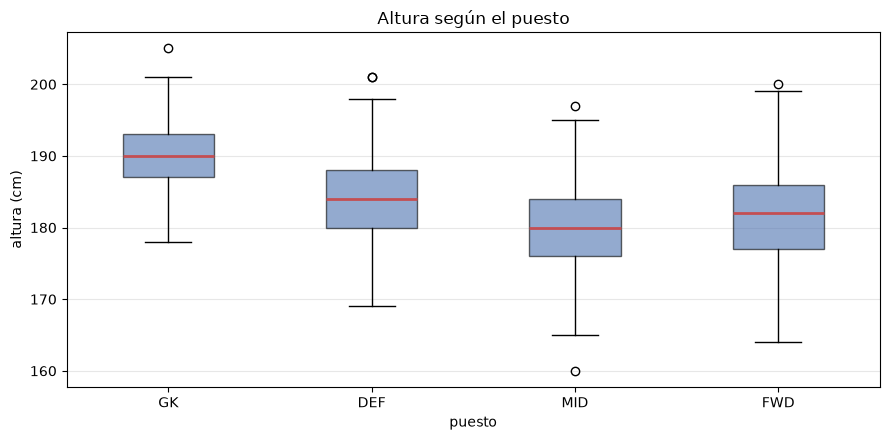

In [13]:
orden = ['GK', 'DEF', 'MID', 'FWD']
datos = [df.loc[df['position'] == p, 'height_cm'] for p in orden]

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.boxplot(datos, patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', alpha=0.6),
           medianprops=dict(color='#C44E52', linewidth=2))
ax.set_xticks(range(1, len(orden) + 1))
ax.set_xticklabels(orden)

ax.set_title('Altura según el puesto')
ax.set_xlabel('puesto')
ax.set_ylabel('altura (cm)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

El puesto **sí** explica la altura, algo que ninguna variable numérica lograba: la mediana baja de
**190 cm en los arqueros** a 184 (DEF), 182 (FWD) y 180 cm (MID). Las cajas de GK (187–193 cm) y
MID (176–184 cm) no se superponen: la diferencia entre esos dos grupos es real y no producto del
azar.

## 7. Conclusiones

1. El dataset es **limpio y balanceado**: 1248 jugadores, 26 por selección, sin nulos ni
   duplicados.
2. Hay **dos familias de distribuciones**. `edad` y `height_cm` son simétricas y se resumen bien
   con la media; `valor_millones`, `caps` y `goals` tienen una cola derecha larga y hay que
   describirlas con la **mediana y el IQR**.
3. La variable que mejor se relaciona con el valor de mercado no es individual sino del equipo:
   **`elo_rating` (+0,57)**. La experiencia (`caps`) es indiferente al valor y la edad se
   relaciona **negativamente** (−0,22): el mercado paga proyección.
4. La relación **categórica–numérica más nítida** es altura por puesto (GK 190 > DEF 184 >
   FWD 182 > MID 180 cm), invisible para la matriz de correlación.
5. Como resultado práctico para un modelo posterior: `valor_millones` conviene transformarla
   (por ejemplo con logaritmo) antes de usarla, y `position` y `elo_rating` son las candidatas
   más informativas.